<img src="banner.png" width="100%" style="max-height:300px; object-fit:cover;"/>

# Curso de Agentes de IA con LangGraph

Este notebook sirve como una guía introductoria para el diseño e implementación de **Agentes de Inteligencia Artificial** utilizando el framework **LangChain** y la integración de la familia **Gemini** a través de **Google Cloud Vertex AI**.

A lo largo de este curso, aprenderemos a:

- Conectar modelos de lenguaje con herramientas externas.
- Crear flujos de trabajo cíclicos basados en grafos.
- Dotar a los sistemas de capacidades de razonamiento.
- Diseñar agentes con toma de decisiones autónoma.

> El objetivo es construir una base sólida para desarrollar agentes inteligentes capaces de interactuar con herramientas, procesar información y ejecutar tareas de forma dinámica.


## Paso 1: Instalación de Dependencias

Para comenzar, instalaremos todas las librerías necesarias para el curso en su versión más reciente. Esto incluye:

- **langchain**, **langchain-community**, **langchain-google-genai**: módulos principales y de integración con Google Generative AI (Gemini).
- **langgraph**: motor para crear agentes basados en grafos con estados y ciclos.
- **python-dotenv**: carga de variables de entorno desde un archivo `.env`.
- **arxiv**: herramienta de búsqueda y consulta académica para ejercicios del curso.

> **Nota:** usamos el parámetro `-q` (*quiet*) para realizar una instalación limpia y libre de barras de progreso ruidosas.


In [20]:
# Instalar dependencias del curso de forma silenciosa
!pip install -q -U langchain langchain-community langgraph langchain-google-genai langchain-tavily google-auth python-dotenv arxiv tavily-python

## Paso 2: Autenticación con Google Cloud (ADC)

Para conectarnos a **Vertex AI** sin usar una API key, utilizamos **Application Default Credentials (ADC)**. Este mecanismo detecta automáticamente las credenciales del entorno local.

Ejecuta los siguientes comandos **una sola vez** desde la terminal integrada de DataSpell (`Alt + F12`):

```bash
# Iniciar sesión con tu cuenta de Google
gcloud auth login

# Generar el archivo de credenciales ADC en tu entorno local
gcloud auth application-default login

# Establecer tu proyecto de Google Cloud (debe tener Vertex AI habilitado)
gcloud config set project TU_PROJECT_ID
```

Las credenciales se almacenan en `%APPDATA%\gcloud\application_default_credentials.json` y son detectadas automáticamente por el SDK.

> **Nota:** el `project_id` se carga desde un archivo `.env` para no hardcodearlo en el código.


## Paso 3: Configuración del Entorno e Importación de Librerías

En este paso, configuraremos el entorno de Python e importaremos las librerías esenciales para trabajar con **LangChain** y **LangGraph**.

Esto incluye:

- **warnings**: módulo utilizado para controlar y filtrar advertencias durante la ejecución del notebook.
- **dotenv**: carga del `GOOGLE_CLOUD_PROJECT` y `TAVILY_API_KEY` desde el archivo `.env`.
- **google.auth**: obtención de credenciales ADC para autenticación con Google Cloud sin API key.
- **langchain-google-genai**: integración de LangChain con los modelos Gemini de Google.
- **LangGraph**: extensión que permite crear flujos de trabajo basados en grafos, estados y ciclos.

> **Nota:** configuraremos un filtro de advertencias para mantener la salida del notebook limpia, evitando mensajes de depreciación o avisos menores que no afecten el desarrollo del curso.


In [21]:
import os
import warnings
from dotenv import load_dotenv

load_dotenv()

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["PYTHONWARNINGS"] = "ignore"

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
import langgraph

print("✅ Entorno configurado e importaciones listas.")

✅ Entorno configurado e importaciones listas.


## Paso 4: Inicialización del Modelo, Herramientas y Prueba de Conexión

En este paso, inicializaremos el modelo **Gemini 2.5 Flash**, definiremos las herramientas del agente y realizaremos una prueba de conexión.

Esto incluye:

- **Inicialización del modelo**: creación de una instancia de `ChatGoogleGenerativeAI` autenticada mediante ADC con Vertex AI.
- **busca_web**: herramienta que realiza búsquedas en la web usando Tavily Search.
- **create_react_agent**: creación del agente con `system_prompt` y herramientas vinculadas.
- **Prueba de conexión**: verificación de que las credenciales ADC y la configuración del entorno están funcionando.

> **Nota:** esta prueba permite confirmar que el entorno está listo para comenzar a trabajar con modelos de lenguaje dentro de flujos creados con LangChain y LangGraph.


In [22]:
import google.auth
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.prebuilt import create_react_agent

# Obtener credenciales ADC y project_id
credentials, project_id = google.auth.default()

# Inicializar el modelo Gemini 2.5 Flash con credenciales ADC
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    credentials=credentials
)

@tool
def busca_web(query: str) -> list:
    """Realiza una búsqueda en la web sobre un tema específico"""
    tavily_search = TavilySearch(max_results=3)
    return tavily_search.invoke(query)

tools = [busca_web]

system_prompt = """
Actúa como un asistente útil y especializado en investigación.
Utiliza las herramientas proporcionadas para responder a las preguntas del usuario.

Herramientas disponibles:
- busca_web: realiza búsquedas en la web y devuelve enlaces y resúmenes.

Siempre que el usuario pregunte sobre un tema específico:
1. Usa la herramienta busca_web.
2. Analiza los resultados.
3. Devuelve una respuesta clara.
4. Incluye los enlaces de las fuentes utilizadas.
"""

agente_web = create_react_agent(
    model=llm,
    tools=tools,
    prompt=system_prompt
)

print("\n🧰 Herramientas registradas:")
for t in tools:
    print(f"  ✅ {t.name:<15} — {t.description}")
print("\n✅ Agente creado con create_react_agent.")


🧰 Herramientas registradas:
  ✅ busca_web       — Realiza una búsqueda en la web sobre un tema específico

✅ Agente creado con create_react_agent.


## Paso 5: Prueba de Herramientas

En este paso probaremos que las herramientas vinculadas al modelo funcionan correctamente de forma independiente.

Esto incluye:

- **busca_web**: el agente detecta que debe buscar en la web y retorna una respuesta elaborada con fuentes.

> **Nota:** el agente maneja el ciclo razonamiento → herramienta → respuesta de forma autónoma usando el patrón ReAct.


In [23]:
import re, html

def limpiar_texto(texto: str) -> str:
    texto = html.unescape(texto)
    texto = re.sub(r'\[.*?\]\(.*?\)', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Prueba con búsqueda web
resultado = agente_web.invoke({
    "messages": [("user", "¿Cuáles son los impactos de la inteligencia artificial en la educación?")]
})

respuesta_final = resultado["messages"][-1]
c = respuesta_final.content
if isinstance(c, list):
    contenido = ' '.join(p['text'] for p in c if isinstance(p, dict) and 'text' in p)
else:
    contenido = c
print("\n🤖 Respuesta del agente:")
print("─" * 60)
print(limpiar_texto(contenido))


🤖 Respuesta del agente:
────────────────────────────────────────────────────────────
La inteligencia artificial (IA) está transformando profundamente el ámbito educativo, presentando tanto oportunidades significativas como desafíos importantes. **Oportunidades y Beneficios:** * **Personalización del aprendizaje:** La IA permite ofrecer tutorías personalizadas y un aprendizaje adaptativo, ajustando el contenido y el ritmo a las necesidades individuales de cada estudiante, lo que potencia el proceso de enseñanza y aprendizaje. * **Asistencia a docentes:** Las herramientas de IA pueden apoyar a los educadores en diversas tareas, agilizando procesos y permitiéndoles concentrarse más en la interacción con los alumnos. * **Optimización de la gestión escolar:** La IA puede procesar grandes volúmenes de datos sobre matrícula, asistencia y recursos, lo que facilita la planificación institucional y mejora la eficiencia administrativa. * **Fortalecimiento de la gobernanza educativa:** Al mejorar

## Paso 6: Agente Científico con ArXiv

En este paso crearemos un agente especializado en búsqueda de artículos académicos usando **ArXiv**.

- **tool_cientifica**: herramienta que consulta arXiv y retorna títulos, autores y resúmenes.
- **agente_cientifico**: agente ReAct con `create_react_agent` vinculado a la herramienta arXiv.

> **Nota:** ArXiv es un repositorio de acceso abierto con más de 2 millones de artículos científicos en física, matemáticas, computación y más.


In [24]:
import arxiv

@tool
def tool_cientifica(query: str) -> str:
    """Busca artículos científicos en arXiv sobre un tema específico"""
    client = arxiv.Client()
    search = arxiv.Search(query=query, max_results=5)
    resultados = []
    for r in client.results(search):
        resultados.append(f"- {r.title} ({r.published.year})\n  {r.entry_id}")
    return "\n".join(resultados) if resultados else "No se encontraron resultados."

system_prompt2 = """
Actúa como un asistente útil.
Usa las herramientas proporcionadas para responder a las preguntas del usuario.

- tool_cientifica: Retorna resultados de una búsqueda en arXiv.

Cuando el usuario pregunte sobre un tema específico, usa tool_cientifica y devuelve los títulos de los artículos encontrados.
"""

agente_cientifico = create_react_agent(
    model=llm,
    tools=[tool_cientifica],
    prompt=system_prompt2
)

resultado = agente_cientifico.invoke({
    "messages": [
        ("user", "AI impact in education")
    ]
})

contenido = resultado["messages"][-1].content
if isinstance(contenido, list):
    print(contenido[0]["text"])
else:
    print(contenido)

Aquí tienes algunos artículos sobre el impacto de la IA en la educación:

- Need of AI in Modern Education: in the Eyes of Explainable AI (xAI) (2024)
- Exploring utilization of generative AI for research and education in data-driven materials science (2025)
- AI & Data Competencies: Scaffolding holistic AI literacy in Higher Education (2025)


## Paso 7: Agentes Especializados Encapsulados

En este paso encapsulamos los agentes web y científico como funciones reutilizables que operan sobre un estado compartido (`AgentState`).

- **AgentState**: estructura de datos que almacena la consulta del usuario y las respuestas de cada agente.
- **funcion_agente_web**: reutiliza `agente_web` del Paso 4 para realizar búsquedas web con Tavily.
- **funcion_agente_cientifico**: reutiliza `agente_cientifico` del Paso 6 para consultar arXiv.

> **Nota:** al reutilizar los agentes ya inicializados se evita reinstanciar el LLM en cada llamada, lo que mejora significativamente el rendimiento.


In [25]:
from typing import TypedDict, Dict

# ====================== ESTADO DEL AGENTE ======================
class AgentState(TypedDict):
    user_query: str
    web_answer: str
    scientific_answer: str
    final_answer: str
    router_decision: str


# ====================== AGENTE WEB (reutiliza agente_web del Paso 4) ======================
def funcion_agente_web(state: AgentState) -> Dict:
    resultado = agente_web.invoke({"messages": [("user", state["user_query"])]})
    respuesta = resultado["messages"][-1].content
    if isinstance(respuesta, list):
        respuesta = " ".join(p["text"] for p in respuesta if isinstance(p, dict) and "text" in p)
    state["web_answer"] = respuesta
    return state


# ====================== AGENTE CIENTÍFICO (reutiliza agente_cientifico del Paso 6) ======================
def funcion_agente_cientifico(state: AgentState) -> Dict:
    resultado = agente_cientifico.invoke({"messages": [("user", state["user_query"])]})
    respuesta = resultado["messages"][-1].content
    if isinstance(respuesta, list):
        respuesta = " ".join(p["text"] for p in respuesta if isinstance(p, dict) and "text" in p)
    state["scientific_answer"] = respuesta
    return state


print("✅ Paso 7: Agentes especializados encapsulados y listos para usar.")


✅ Paso 7: Agentes especializados encapsulados y listos para usar.


## Paso 7.1: Prueba de Agentes Simultáneos con Salida Formateada

En este paso probaremos ambos agentes funcionando de forma **paralela** sobre la misma consulta del usuario, recolectando y formateando sus respuestas de forma legible.

- **Ejecución concurrente**: usa threading para ejecutar web + científico en paralelo.
- **Salida formateada**: cada respuesta se muestra con encabezados claros y separadores visuales.
- **Agregación**: combina ambas respuestas en una salida final integrada.


In [26]:
import threading

consulta_usuario = "¿Cuál es el impacto de la inteligencia artificial en la educación?"
consulta_en = "What is the impact of artificial intelligence in education?"

state_web = AgentState(user_query=consulta_usuario, web_answer="", scientific_answer="", final_answer="")
state_cien = AgentState(user_query=consulta_en, web_answer="", scientific_answer="", final_answer="")

# Resultados locales para evitar race conditions
resultados = {"web": "", "cientifico": ""}

def ejecutar_web():
    try:
        print("🔍 [WEB] Iniciando búsqueda web...")
        funcion_agente_web(state_web)
        resultados["web"] = state_web["web_answer"]
        print("✅ [WEB] Búsqueda completada\n")
    except Exception as e:
        resultados["web"] = f"❌ Error en agente web: {str(e)}"
        print(f"❌ [WEB] Error: {e}\n")

def ejecutar_cientifico():
    try:
        print("📚 [CIENTÍFICO] Iniciando búsqueda en arXiv...")
        funcion_agente_cientifico(state_cien)
        resultados["cientifico"] = state_cien["scientific_answer"]
        print("✅ [CIENTÍFICO] Búsqueda completada\n")
    except Exception as e:
        resultados["cientifico"] = f"❌ Error en agente científico: {str(e)}"
        print(f"❌ [CIENTÍFICO] Error: {e}\n")

# Ejecutar agentes en paralelo usando threading
print("\n🚀 Ejecutando agentes en paralelo...\n")
print("=" * 70)

thread_web = threading.Thread(target=ejecutar_web)
thread_cientifico = threading.Thread(target=ejecutar_cientifico)

thread_web.start()
thread_cientifico.start()
thread_web.join()
thread_cientifico.join()

print("=" * 70)
print("\n📊 RESULTADOS CONSOLIDADOS\n")

# Mostrar respuesta WEB
print("\n" + "─" * 70)
print("  🌐 RESPUESTA WEB (Tavily)")
print("─" * 70)
print()
respuesta_web = limpiar_texto(resultados['web'])
for i, linea in enumerate(respuesta_web.split('. '), 1):
    if linea.strip():
        print(f"  {i}. {linea.strip()}." if not linea.strip().endswith('.') else f"  {i}. {linea.strip()}")

# Mostrar respuesta CIENTÍFICA
print("\n" + "─" * 70)
print("  📚 RESPUESTA CIENTÍFICA (arXiv)")
print("─" * 70)
print()
respuesta_cientifica = limpiar_texto(resultados['cientifico'])
print(f"  {respuesta_cientifica}")

# Resumen final
print("\n" + "=" * 70)
print("\n✨ ESTADO FINAL DEL AGENTE\n")
print(f"📝 Consulta: {consulta_usuario}")
print(f"🌐 Respuesta Web: {len(resultados['web'])} caracteres")
print(f"📚 Respuesta Científica: {len(resultados['cientifico'])} caracteres")
print("\n" + "=" * 70)


🚀 Ejecutando agentes en paralelo...

🔍 [WEB] Iniciando búsqueda web...
📚 [CIENTÍFICO] Iniciando búsqueda en arXiv...
✅ [CIENTÍFICO] Búsqueda completada

✅ [WEB] Búsqueda completada


📊 RESULTADOS CONSOLIDADOS


──────────────────────────────────────────────────────────────────────
  🌐 RESPUESTA WEB (Tavily)
──────────────────────────────────────────────────────────────────────

  1. La inteligencia artificial (IA) está transformando el panorama educativo, presentando tanto oportunidades significativas como desafíos importantes.
  2. **Impactos Positivos y Oportunidades:** * **Personalización del aprendizaje:** La IA permite adaptar la enseñanza a las necesidades individuales de cada estudiante, ajustando el ritmo y el contenido para optimizar el proceso de aprendizaje.
  3. * **Mejora de procesos cognitivos:** Puede potenciar habilidades como la atención, la memoria, la resolución de problemas y el pensamiento crítico, tanto en estudiantes como en docentes.
  4. * **Detección de patro

## Paso 8: Definiendo un grafo para combinar agentes

En este paso conectamos los agentes especializados dentro de un **grafo secuencial** construido con LangGraph. El grafo define el orden de ejecución de los nodos y cómo fluye el estado entre ellos.

El flujo es el siguiente:

1. **`web_search`**: ejecuta el agente web (Tavily) y almacena la respuesta en el estado.
2. **`scientific_search`**: ejecuta el agente científico (arXiv) y almacena su respuesta en el estado.
3. **`supervisor`**: toma ambas respuestas del estado compartido y las consolida en una respuesta final estructurada.

Este patrón es la base de los sistemas multi-agente: cada nodo es un agente especializado que contribuye con su parte, y un nodo supervisor integra los resultados.

> **Nota:** `StateGraph` de LangGraph gestiona el estado compartido (`AgentState`) a lo largo de todo el flujo, permitiendo que cada nodo lea y escriba en él de forma ordenada.


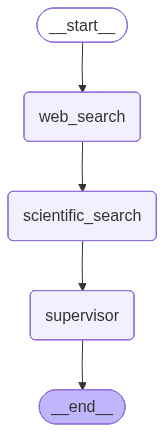

### Resultados combinados de búsqueda

### Resultados desde la web
La inteligencia artificial (IA) está teniendo un impacto significativo en la medicina, prometiendo una transformación profunda en el cuidado de la salud. Aquí te presento los puntos clave de su impacto:

*   **Optimización y eficiencia**: La IA mejora la gestión hospitalaria, acelera la investigación biomédica y reduce la carga administrativa de los profesionales de la salud, permitiéndoles dedicar más tiempo a la atención del paciente.
*   **Mejora del diagnóstico y tratamiento**: La IA puede ayudar a los médicos a identificar indicadores específicos para mejorar la precisión diagnóstica, personalizar tratamientos y optimizar los resultados para los pacientes.
*   **Automatización de tareas repetitivas**: Al automatizar actividades rutinarias y repetitivas, la IA libera tiempo para el personal de salud, lo que potencialmente puede mejorar la relación médico-paciente.
*   **Transformación del cuidado de la salud**: Algu

In [27]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display


def supervisor_node(state: AgentState) -> dict:
    web_results = state.get("web_answer", "No se realizó búsqueda web.")
    scientific_results = state.get("scientific_answer", "No se realizó búsqueda científica.")

    final_answer = "### Resultados combinados de búsqueda\n\n"
    final_answer += "### Resultados desde la web\n" + web_results + "\n\n"
    final_answer += "### Artículos científicos\n" + scientific_results + "\n\n"

    return {"final_answer": final_answer}


workflow = StateGraph(AgentState)

workflow.add_node("web_search", funcion_agente_web)
workflow.add_node("scientific_search", funcion_agente_cientifico)
workflow.add_node("supervisor", supervisor_node)

workflow.add_edge(START, "web_search")
workflow.add_edge("web_search", "scientific_search")
workflow.add_edge("scientific_search", "supervisor")
workflow.add_edge("supervisor", END)

app = workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

resultado = app.invoke({
    "user_query": "Cuál es el impacto de la IA en la medicina"
})

print(resultado["final_answer"])


## Paso 9: Orquestación de agentes

En este paso evolucionamos el grafo del Paso 8 agregando un nodo **router** con lógica condicional. En lugar de ejecutar siempre ambos agentes, el router analiza la consulta del usuario y decide cuál agente es el más apropiado para responderla.

El flujo es el siguiente:

1. **`router`**: recibe la consulta del usuario, la analiza con el LLM y devuelve `web_search` o `scientific_search` como decisión.
2. **`web_search`** o **`scientific_search`**: solo se ejecuta el agente seleccionado por el router, evitando llamadas innecesarias.
3. **`supervisor`**: recibe el estado con la respuesta del agente invocado y construye la respuesta final consolidada.

La diferencia clave con el Paso 8 es el uso de `add_conditional_edges`, que permite bifurcar el flujo del grafo en tiempo de ejecución según el valor de `router_decision` en el estado.

Conceptos clave de este paso:

- **Enrutamiento condicional**: el grafo no sigue un camino fijo, sino que elige dinámicamente según el contexto.
- **Agente sin herramientas**: el router es un `create_react_agent` con `tools=[]`, usado solo para razonar y clasificar.
- **Estado compartido**: `AgentState` sigue siendo el mecanismo que conecta todos los nodos del grafo.

> **Nota:** este patrón de router + agentes especializados es uno de los más usados en sistemas multi-agente reales, ya que evita ejecutar agentes innecesarios y optimiza el uso de recursos.


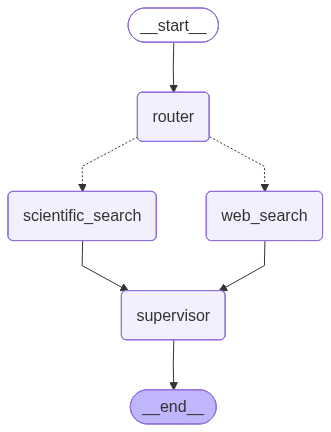

### Resultados combinados de búsqueda

### Resultados desde la web
La Inteligencia Artificial (IA) está generando un impacto significativo en la educación, transformando tanto la enseñanza como el aprendizaje. Sus aplicaciones ofrecen diversas oportunidades, pero también plantean importantes desafíos que deben ser abordados.

**Impactos Positivos y Oportunidades:**

*   **Personalización del Aprendizaje:** La IA permite adaptar el contenido y el ritmo de aprendizaje a las necesidades individuales de cada estudiante, ofreciendo tutorías personalizadas y aprendizaje adaptativo. Esto mejora procesos cognitivos como la atención, la memoria y la resolución de problemas.
*   **Mejora de Procesos Cognitivos:** La IA puede contribuir a potenciar la atención, la memoria, la resolución de problemas y el pensamiento crítico tanto en estudiantes como en profesores.
*   **Asistencia a Docentes:** Las herramientas de IA pueden agilizar tareas administrativas, permitiendo a los educadores enfocarse m

In [28]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display

# ==================== PROMPT DEL ROUTER ====================
router_prompt = """Eres un agente ruteador. Tu tarea es decidir cuál agente es más apropiado 
para responder la pregunta del usuario.

Pregunta del usuario: {user_query}

Puedes elegir entre las siguientes opciones:
- web_search: Usa esta opción si la pregunta requiere una búsqueda general en internet.
- scientific_search: Usa esta opción si la pregunta requiere artículos científicos.

Responde ÚNICAMENTE con el nombre de la opción (web_search o scientific_search)."""

# ==================== NODO ROUTER ====================
def router_agent(state: AgentState) -> dict:
    router_agent_instance = create_react_agent(
        model=llm,
        tools=[],
        prompt=router_prompt
    )
    
    response = router_agent_instance.invoke({
        "messages": [("user", state["user_query"])]
    })
    
    decision = response["messages"][-1].content.strip().lower()
    
    if decision == "web_search":
        return {"router_decision": "web_search"}
    elif decision == "scientific_search":
        return {"router_decision": "scientific_search"}
    else:
        return {"router_decision": "web_search"}


# ==================== NODO SUPERVISOR ====================
def supervisor_node(state: AgentState) -> dict:
    web_results = state.get("web_answer", "No se realizó búsqueda web.")
    scientific_results = state.get("scientific_answer", "No se realizó búsqueda científica.")
    
    final_answer = "### Resultados combinados de búsqueda\n\n"
    final_answer += "### Resultados desde la web\n" + web_results + "\n\n"
    final_answer += "### Artículos científicos\n" + scientific_results + "\n\n"
    
    return {"final_answer": final_answer}


# ==================== CREACIÓN DEL GRAFO ====================
workflow = StateGraph(AgentState)

workflow.add_node("router", router_agent)
workflow.add_node("web_search", funcion_agente_web)
workflow.add_node("scientific_search", funcion_agente_cientifico)
workflow.add_node("supervisor", supervisor_node)

workflow.add_edge(START, "router")

workflow.add_conditional_edges(
    "router",
    lambda state: state["router_decision"],
    {
        "web_search": "web_search",
        "scientific_search": "scientific_search"
    }
)

workflow.add_edge("web_search", "supervisor")
workflow.add_edge("scientific_search", "supervisor")
workflow.add_edge("supervisor", END)

app = workflow.compile()

# Mostrar grafo
display(Image(app.get_graph().draw_mermaid_png()))

# ==================== PRUEBAS ====================

# Prueba 1: Solo fuentes web
resultado = app.invoke({
    "user_query": "Cuál es el impacto de la IA en la Educación? Usa solo fuentes web"
})

print(resultado.get("final_answer"))

# Prueba 2: Solo fuentes científicas (comentada por ahora)
# resultado = app.invoke({
#     "user_query": "Cuál es el impacto de la IA en la Educación? Usa solo fuentes científicas"
# })

# print(resultado.get("final_answer"))


## Paso 10: Interfaz Web Interactiva con Gradio

En este último paso exponemos el sistema multi-agente del Paso 9 a través de una **interfaz web interactiva** construida con **Gradio**, permitiendo a cualquier usuario interactuar con el sistema sin escribir código.

### Componentes de este paso:

1. **Cierre de interfaces previas**: `gr.close_all()` garantiza que no haya conflictos de puertos con ejecuciones anteriores.

2. **Diseño personalizado**: CSS moderno con gradiente morado/azul, tarjeta blanca centrada y componentes con bordes redondeados.

3. **Función `run_graph`**: ejecuta el grafo completo del Paso 9 (`app.invoke()`) y retorna la respuesta final formateada en Markdown.

4. **Arquitectura con `gr.Blocks`**: permite un control total sobre el layout, a diferencia de `gr.Interface` que tiene un diseño fijo.

5. **Elementos de la interfaz**:
   - **Header**: título, subtítulo y badge informativo de agentes activos
   - **Input**: caja de texto para la consulta del usuario
   - **Botón de envío**: con estilo degradado y efecto hover
   - **Output**: área de respuesta en formato Markdown
   - **Ejemplos**: tres consultas predefinidas para probar rápidamente

6. **Event handlers**: el sistema responde tanto al clic del botón como al presionar Enter en el input.

7. **Puerto automático**: `server_port=None` permite que Gradio seleccione un puerto libre automáticamente (evita conflictos).

### Flujo completo:

```
Usuario escribe consulta
    ↓
run_graph() invoca app.invoke()
    ↓
Router decide: web_search o scientific_search
    ↓
Agente especializado ejecuta búsqueda
    ↓
Supervisor consolida resultados
    ↓
Respuesta se muestra en formato Markdown
```

### Ventajas de esta arquitectura:

- **Accesibilidad**: cualquier persona puede usar el sistema sin conocimientos de programación.
- **Reutilización**: la interfaz web usa el mismo grafo `app` del Paso 9, sin duplicar lógica.
- **Escalabilidad**: se puede agregar autenticación, logging, métricas, etc.
- **Portabilidad**: cambiar `share=True` genera un enlace público temporal para compartir la demo.

> **Nota:** esta arquitectura es la base de aplicaciones de IA en producción: backend con LangGraph + frontend con Gradio/Streamlit, separando la lógica de negocio de la presentación.

In [29]:
# Celda paso 10

import gradio as gr

# ==================== CERRAR INTERFACES ANTERIORES ====================
try:
    gr.close_all()
    print("✓ Interfaces anteriores cerradas")
except:
    pass

# ==================== CSS ESTILO MODERNO TECH ====================
custom_css = """
    .gradio-container {
        max-width: 900px !important;
        margin: auto !important;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
        padding: 20px !important;
    }
    
    .main-container {
        background: rgba(255, 255, 255, 0.95) !important;
        border-radius: 20px !important;
        padding: 40px !important;
        box-shadow: 0 20px 60px rgba(0,0,0,0.3) !important;
    }
    
    .title-text {
        text-align: center !important;
        font-size: 2.5em !important;
        font-weight: 800 !important;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
        -webkit-background-clip: text !important;
        -webkit-text-fill-color: transparent !important;
        margin-bottom: 10px !important;
        font-family: 'Segoe UI', system-ui, sans-serif !important;
    }
    
    .subtitle-text {
        text-align: center !important;
        color: #6b7280 !important;
        font-size: 1.1em !important;
        margin-bottom: 30px !important;
        font-weight: 500 !important;
    }
    
    .input-container, .output-container {
        margin: 20px 0 !important;
    }
    
    textarea, .gr-text-input {
        border: 2px solid #e5e7eb !important;
        border-radius: 12px !important;
        padding: 15px !important;
        font-size: 16px !important;
        transition: all 0.3s ease !important;
    }
    
    textarea:focus, .gr-text-input:focus {
        border-color: #667eea !important;
        box-shadow: 0 0 0 3px rgba(102, 126, 234, 0.1) !important;
        outline: none !important;
    }
    
    .gr-button {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
        border: none !important;
        border-radius: 12px !important;
        padding: 12px 40px !important;
        font-size: 16px !important;
        font-weight: 600 !important;
        color: white !important;
        cursor: pointer !important;
        transition: all 0.3s ease !important;
        margin: 20px auto !important;
        display: block !important;
    }
    
    .gr-button:hover {
        transform: translateY(-2px) !important;
        box-shadow: 0 10px 25px rgba(102, 126, 234, 0.4) !important;
    }
    
    .output-markdown {
        background: #f9fafb !important;
        border: 2px solid #e5e7eb !important;
        border-radius: 12px !important;
        padding: 20px !important;
        min-height: 200px !important;
        font-size: 15px !important;
        line-height: 1.6 !important;
    }
    
    label {
        font-weight: 600 !important;
        color: #374151 !important;
        margin-bottom: 8px !important;
        display: block !important;
        font-size: 14px !important;
        text-transform: uppercase !important;
        letter-spacing: 0.5px !important;
    }
    
    .status-badge {
        display: inline-block !important;
        padding: 6px 16px !important;
        background: linear-gradient(135deg, #10b981 0%, #059669 100%) !important;
        color: white !important;
        border-radius: 20px !important;
        font-size: 0.85em !important;
        font-weight: 600 !important;
        margin: 10px auto !important;
        text-align: center !important;
    }
    
    .info-box {
        background: linear-gradient(135deg, #eff6ff 0%, #dbeafe 100%) !important;
        border-left: 4px solid #3b82f6 !important;
        padding: 15px 20px !important;
        border-radius: 8px !important;
        margin: 20px 0 !important;
        font-size: 14px !important;
        color: #1e40af !important;
    }
"""

# ==================== FUNCIÓN run_graph ====================
def run_graph(user_query: str):
    """
    Ejecuta el grafo de agentes y retorna la respuesta final.
    """
    if not user_query.strip():
        return "⚠️ **Error:** Por favor ingresa una consulta válida."
    
    try:
        resultado = app.invoke({
            "user_query": user_query
        })
        return resultado.get("final_answer", "❌ No se obtuvo respuesta del sistema.")
    except Exception as e:
        return f"❌ **Error al procesar la consulta:**\n\n```\n{str(e)}\n```"

# ==================== INTERFAZ GRADIO CON BLOCKS ====================
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as iface:
    
    with gr.Column(elem_classes="main-container"):
        # Header
        gr.HTML("""
            <div class="title-text">🤖 NeuroNet AI</div>
            <div class="subtitle-text">Sistema Inteligente de Búsqueda Híbrida</div>
            <div class="info-box">
                ✨ <strong>Agentes Activos:</strong> Búsqueda Web (Tavily) • Búsqueda Científica (arXiv)
            </div>
        """)
        
        # Input section
        with gr.Row():
            with gr.Column(scale=1):
                user_input = gr.Textbox(
                    label="💬 Tu Consulta",
                    placeholder="Ejemplo: ¿Cuál es el impacto de la IA en la medicina?",
                    lines=3,
                    elem_classes="input-container"
                )
        
        # Submit button
        submit_btn = gr.Button("🚀 Buscar Respuesta", variant="primary")
        
        # Output section
        with gr.Row():
            with gr.Column(scale=1):
                output = gr.Markdown(
                    label="📊 Respuesta del Sistema",
                    elem_classes="output-container"
                )
        
        # Status
        gr.HTML('<div class="status-badge">✓ Sistema Listo</div>')
        
        # Examples
        gr.Examples(
            examples=[
                ["¿Cuál es el impacto de la IA en la medicina?"],
                ["¿Qué avances hay en energía renovable?"],
                ["Explica el aprendizaje por refuerzo"],
            ],
            inputs=user_input,
            label="💡 Ejemplos de Consultas"
        )
    
    # Event handlers
    submit_btn.click(
        fn=run_graph,
        inputs=user_input,
        outputs=output
    )
    
    user_input.submit(
        fn=run_graph,
        inputs=user_input,
        outputs=output
    )

# ==================== LANZAR LA INTERFAZ ====================
print("\n🚀 Iniciando interfaz web...")
iface.launch(
    server_name="127.0.0.1",
    server_port=None,  # Gradio encontrará un puerto libre automáticamente
    share=False,  # Cambia a True si quieres un enlace público
    show_error=True,
    quiet=False
)
print("✅ Interfaz lista. Presiona el enlace arriba para acceder.")

Closing server running on port: 7860
✓ Interfaces anteriores cerradas

🚀 Iniciando interfaz web...
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


✅ Interfaz lista. Presiona el enlace arriba para acceder.
